# Practice 7.
## Guillem Moreno Garcia
Objectives:

1. Understand the Random Forests.
2. See the effects of changing the parameters of the tree.
3. AQplication:
Data base: Datasets for "The Elements of Statistical Learning" (https://web.stanford.edu/~hastie/ElemStatLearn/data.html)

Database: coronary heart disease (CHD), https://web.stanford.edu/~hastie/ElemStatLearn/datasets/SAheart.data

Predict CHD (1 or 0)
4. Reference: L. Breiman, “Random Forests”, Machine Learning, 45(1), 5-32, 2001.

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import  RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## Let us load the database and   clean it up.

In [2]:
File = "SouthAfricanHeartDesease.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T

Filename with path: 
 C:\mlearn-lab\SeventhPractice\Data\SouthAfricanHeartDesease.csv


,0,1,2,3,4
row.names,1,2,3,4,5
sbp,160,144,118,170,134
tobacco,12.0,0.01,0.08,7.5,13.6
ldl,5.73,4.41,3.48,6.41,3.5
adiposity,23.11,28.61,32.28,38.03,27.78
famhist,Present,Absent,Present,Present,Present
typea,49,55,52,51,60
obesity,25.3,28.87,29.14,31.99,25.99
alcohol,97.2,2.06,3.81,24.26,57.34
age,52,63,46,58,49


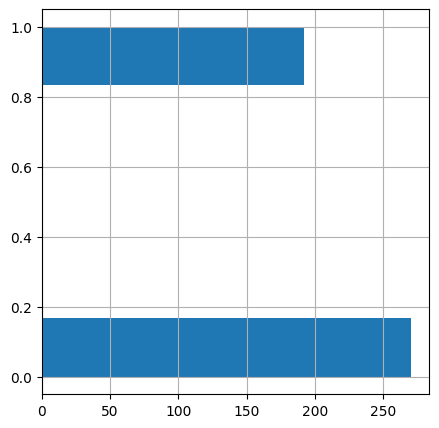

In [3]:
Coding_famhist ={'Present':1,'Absent':0}
Data['famhist'] = Data['famhist'].map(Coding_famhist)
ax =Data['famhist'].hist(figsize= (5,5),orientation="horizontal",bins = 6)

Data.drop(columns = ['row.names'],inplace = True)

##  First we partition database into train and test
### Note the helper function

In [4]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB


In [5]:
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)
y = TrainDB['chd']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'chd']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age']
__________________________________________________


##  Now we create the object Random Forest and fit it

In [6]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', oob_score=True,n_jobs=4, min_samples_split=2, min_samples_leaf=1)
clf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


###  We compute the error on the test database  and compare it with the out of bag estimate

In [7]:
# 1. Prepare the test data using the same features as the training set
X_test = TestDB[InputFeatures]
y_test = TestDB['chd']

# 2. Compute the accuracy on the test set 
test_accuracy = clf.score(X_test, y_test)
test_error = 1 - test_accuracy

# 3. Compute the OOB error rate (1 - oob_score_)
oob_error = 1 - clf.oob_score_

# 4. Print the performance results
print(f'Out of Bag estimate of the error: {oob_error*100:2.2f} %')
print(f'Test database error rate:        {test_error*100:2.2f} %')


Out of Bag estimate of the error: 29.77 %
Test database error rate:        33.62 %


 ###  <font color='red'> Excercise: </font>
 1. Run several times: TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75), and compare the Out of Bag Estimate and the test database error rate.
 2. Explain in one sentence why the out of bag is usefull.

Comparison across different train/test split seeds


,split_seed,oob_error,test_error,test_accuracy,false_negatives,true_positives,sensitivity
0,1,32.66,32.76,67.24,29,14,32.56
1,2,32.37,31.03,68.97,19,13,40.62
2,3,31.79,26.72,73.28,26,13,33.33
3,4,31.21,31.90,68.10,23,16,41.03
4,5,28.32,37.07,62.93,27,12,30.77
5,6,28.61,34.48,65.52,19,19,50.00
6,7,33.53,32.76,67.24,33,13,28.26
7,8,33.24,25.86,74.14,24,22,47.83
8,9,35.26,25.00,75.00,14,20,58.82
9,10,30.64,30.17,69.83,23,21,47.73


Summary of seed variability (%)


,oob_error,test_error,test_accuracy,sensitivity
mean,31.76,30.78,69.22,41.09
std,2.16,3.90,3.90,9.93
min,28.32,25.00,62.93,28.26
max,35.26,37.07,75.00,58.82


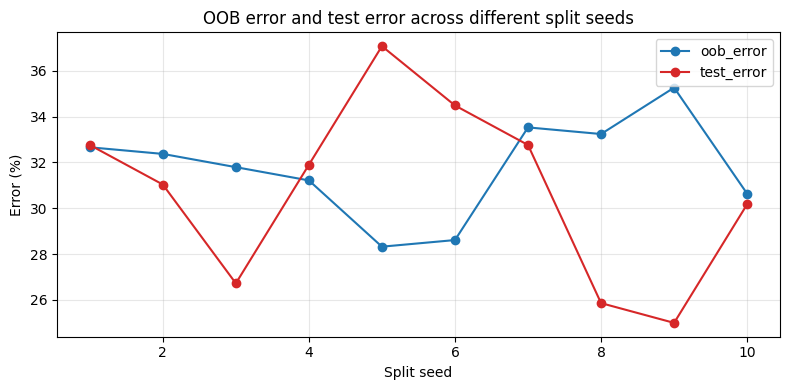

In [8]:
def PartitionOfDatabaseWithSeed(Data, Fraction=0.75, Seed=None):
    NumSamples, NumFeatures = Data.shape
    Index = np.arange(NumSamples)
    if Seed is None:
        RandomIndex = np.random.permutation(Index)
    else:
        RandomIndex = np.random.default_rng(Seed).permutation(Index)
    NumTrainElements = int(Fraction * NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB_seed = Data.iloc[TrainIndex]
    TestDB_seed = Data.iloc[TestIndex]
    return TrainDB_seed, TestDB_seed


def evaluate_random_forest(TrainDB_eval, TestDB_eval, n_estimators=100, model_seed=None, class_weight=None):
    X_train_eval = TrainDB_eval[InputFeatures]
    y_train_eval = TrainDB_eval['chd']
    X_test_eval = TestDB_eval[InputFeatures]
    y_test_eval = TestDB_eval['chd']

    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_features='sqrt',
        oob_score=True,
        n_jobs=4,
        min_samples_split=2,
        min_samples_leaf=1,
        class_weight=class_weight,
        random_state=model_seed
    )
    model.fit(X_train_eval, y_train_eval)
    y_pred_eval = model.predict(X_test_eval)
    cm_eval = confusion_matrix(y_test_eval, y_pred_eval, labels=[0, 1])
    tn, fp, fn, tp = cm_eval.ravel()
    accuracy_eval = accuracy_score(y_test_eval, y_pred_eval)
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else np.nan
    specificity = tn / (tn + fp) if (tn + fp) > 0 else np.nan

    metrics = {
        'oob_error': 1 - model.oob_score_,
        'test_error': 1 - accuracy_eval,
        'test_accuracy': accuracy_eval,
        'false_negatives': fn,
        'true_positives': tp,
        'false_positives': fp,
        'true_negatives': tn,
        'sensitivity': sensitivity,
        'specificity': specificity
    }
    return model, metrics

split_seed_results = []
for split_seed in range(1, 11):
    TrainDB_seed, TestDB_seed = PartitionOfDatabaseWithSeed(Data, Fraction=0.75, Seed=split_seed)
    _, metrics = evaluate_random_forest(
        TrainDB_seed,
        TestDB_seed,
        n_estimators=100,
        model_seed=split_seed
    )
    split_seed_results.append({'split_seed': split_seed, **metrics})

seed_results = pd.DataFrame(split_seed_results)
seed_results_display = seed_results.copy()
for col in ['oob_error', 'test_error', 'test_accuracy', 'sensitivity', 'specificity']:
    seed_results_display[col] = 100 * seed_results_display[col]

print('Comparison across different train/test split seeds')
display(seed_results_display[[
    'split_seed', 'oob_error', 'test_error', 'test_accuracy',
    'false_negatives', 'true_positives', 'sensitivity'
]].round(2))

seed_summary = seed_results[['oob_error', 'test_error', 'test_accuracy', 'sensitivity']].agg(['mean', 'std', 'min', 'max'])
print('Summary of seed variability (%)')
display((100 * seed_summary).round(2))

ax = seed_results_display.plot(
    x='split_seed',
    y=['oob_error', 'test_error'],
    marker='o',
    figsize=(8, 4),
    color=['#1f77b4', '#d62728']
)
ax.set_title('OOB error and test error across different split seeds')
ax.set_xlabel('Split seed')
ax.set_ylabel('Error (%)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Answer:** The OOB error and the test error are usually in the same range, but they are not identical for every split. Changing the seed changes which patients are assigned to train and test, so the test error and the number of false negatives can move noticeably. The Out-of-Bag estimate is useful because it gives an internal estimate of generalization error by evaluating each training observation only with trees that did not use that observation in their bootstrap sample.

## Let us see the importance of the variables

In [9]:
importances = clf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': InputFeatures,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print('\n' + '='*40)
print(f'{"RANKED FEATURE IMPORTANCES":^40}')
print('='*40)
print(feature_importance_df.to_string(index=False, formatters={'Importance': '{:.4f}'.format}))
print('='*40)


       RANKED FEATURE IMPORTANCES       
  Feature Importance
      age     0.1598
  tobacco     0.1488
      ldl     0.1315
adiposity     0.1175
    typea     0.1103
  obesity     0.1022
      sbp     0.0965
  alcohol     0.0825
  famhist     0.0510


### We will use pandas to create a visualization

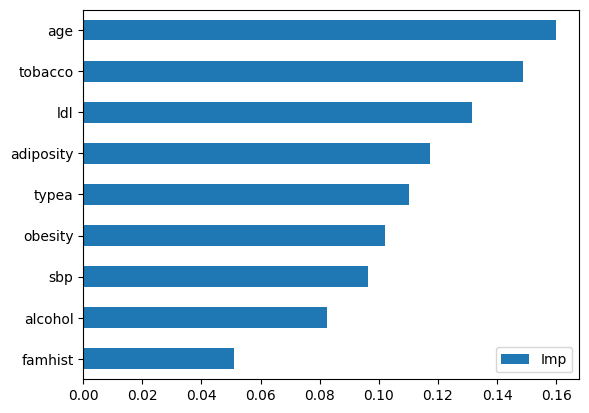

In [10]:
FeaImp=pd.DataFrame(data =clf.feature_importances_,index =  InputFeatures,columns = ['Imp'])
FeaImp.sort_values(by = ['Imp'],inplace = True)
ax = FeaImp.plot.barh()

## Remember the tree we created in the last practice

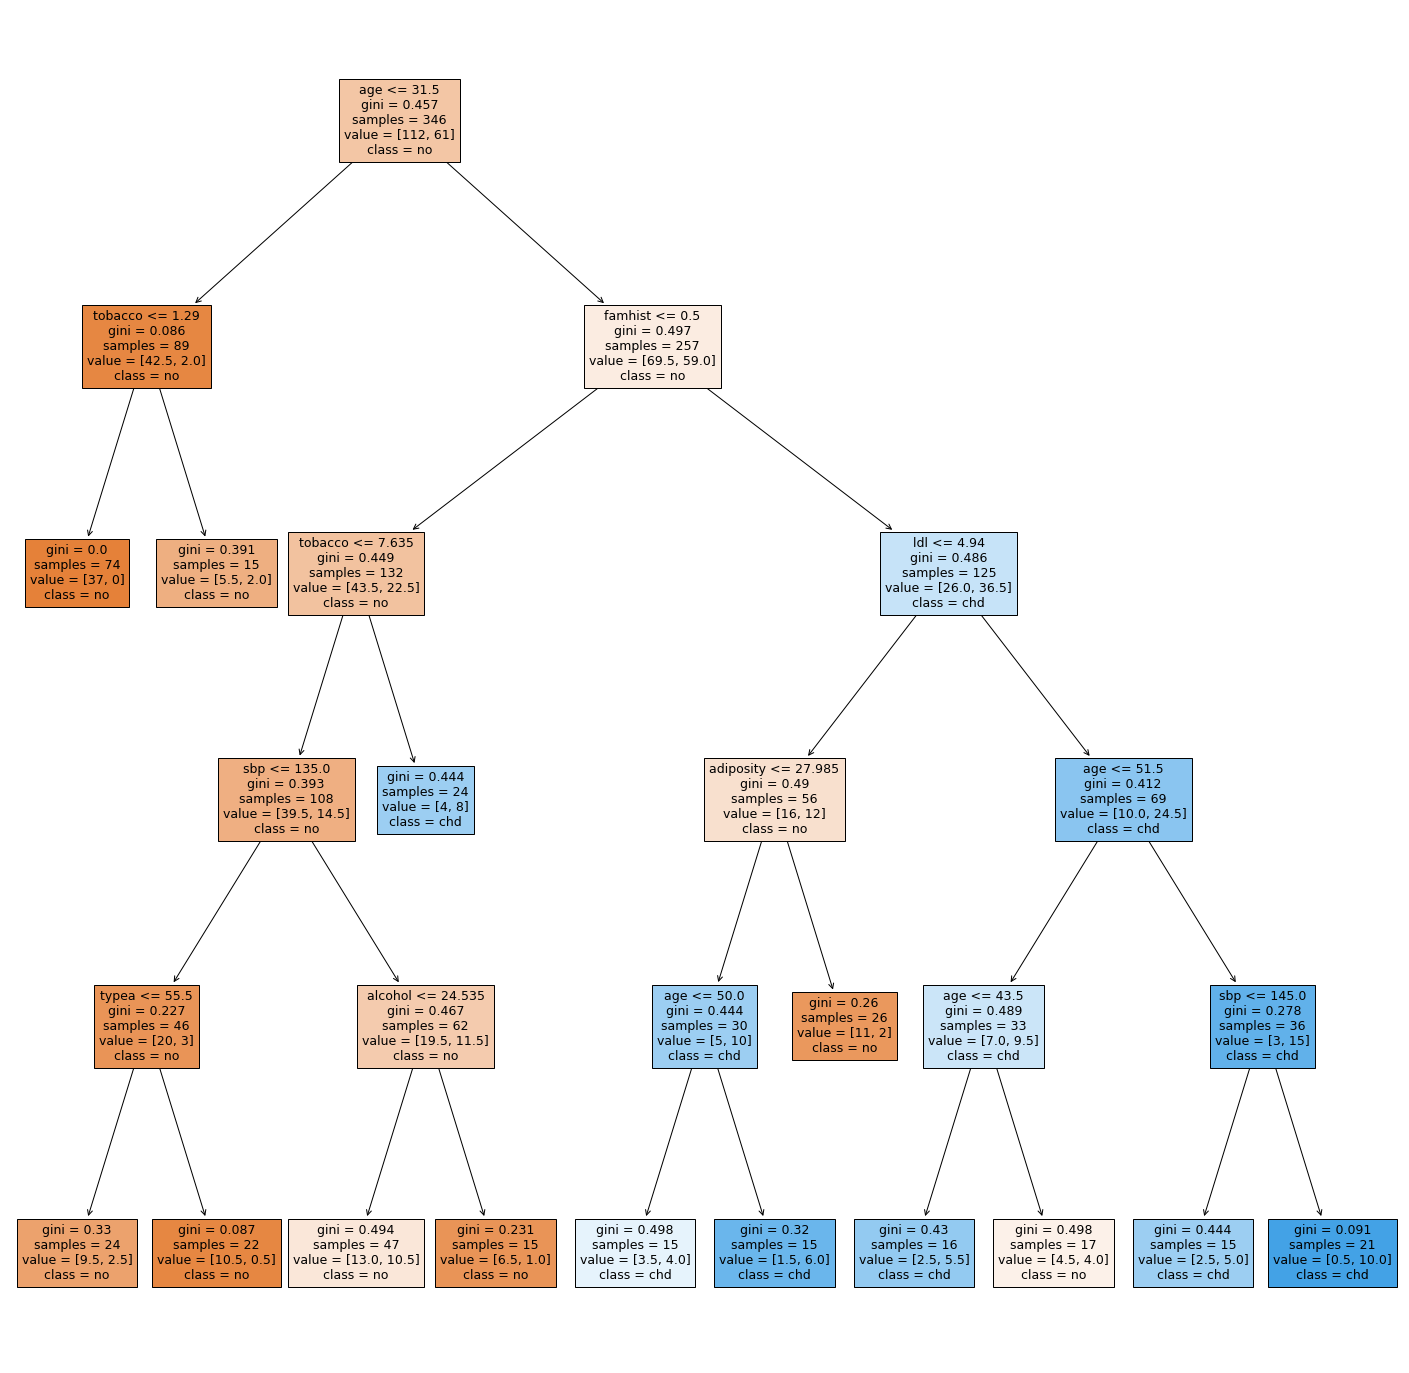

###  <font color='red'> Excercise: </font>
 1. Compare the ranking of the decision tree with the ranking given by the random forest. Provide a one parragraph explanation of the similarities. Note that family history is high in the hierarchy of decision trees but low in the one of random forests. In the explanation reflect about the fact that random forests is simulating a universe of different databases.

**Answer:** The decision tree from the previous practice gives one single hierarchy of questions, so a variable such as `famhist` can appear very high if it creates a good early split in that particular training sample. The Random Forest ranking is more stable because it averages many trees trained on many bootstrap versions of the data and with random subsets of variables. In the current forest, variables such as `age`, `tobacco`, `ldl`, `adiposity`, `sbp`, and `obesity` tend to share the highest importance because they repeatedly help reduce impurity across many simulated databases. `famhist` is still medically meaningful, but its average importance becomes lower because many trees can replace it with other correlated risk factors. Therefore, the two methods agree that cardiovascular risk factors matter, but the forest is less dependent on one particular tree hierarchy.

##  Performance on train
**Definition:**
$\texttt{accuracy}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples}-1} 1(\hat{y}_i = y_i)$


Accuracy (train)  100.0% 
[[226   0]
 [  0 120]]


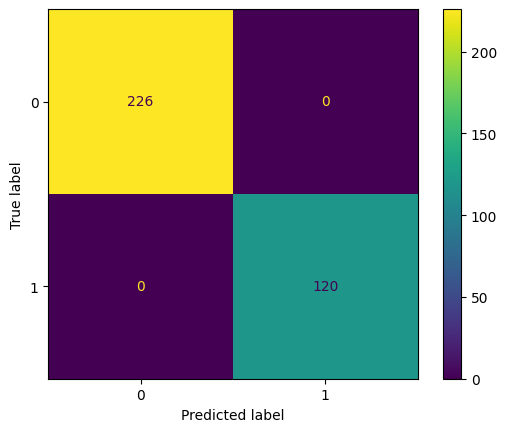

In [11]:
y_hat = clf.predict(X)
accuracy = accuracy_score(y, y_hat)
print("Accuracy (train)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y, y_hat))
ConfusionMatrixDisplay.from_predictions(y, y_hat)
plt.show()

## Remember for a single tree we had 
Accuracy (train)  78.6% 

[[195  29]

 [ 45  77]]

## Performance on test
### Note it is almost the same that the Out of Bag estimate.

Accuracy (test)  66.4% 
[[57 19]
 [20 20]]


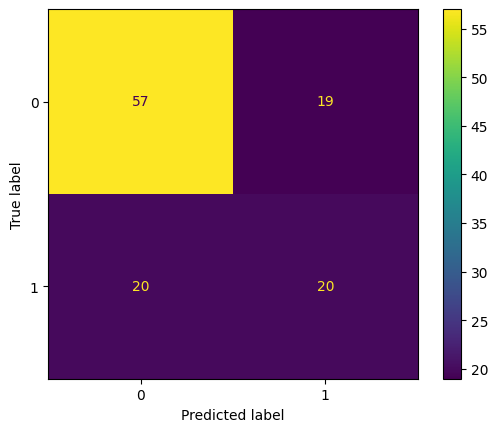

In [12]:
y_tst = TestDB['chd']
X_tst = TestDB[InputFeatures]
y_hat_tst = clf.predict(X_tst)
accuracy = accuracy_score(y_tst, y_hat_tst)
print("Accuracy (test)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y_tst, y_hat_tst))
ConfusionMatrixDisplay.from_predictions(y_tst, y_hat_tst)
plt.show()

## Better than the case of one only tree
Accuracy (test)  63.8% 

[[58 20]
 
 [22 16]]


### Homework: <font color='red'>   Plot the evolution of the Out of Bag error and the test error as a function of the number of trees.  For instance from 100 to 2000 in increments of 100.</font> 

### Homework: <font color='red'>    **Important**: we still have too many false negatives. Try  changing the class_weight = {0:0.5,1:0.5}.  </font>



Evolution of OOB and test error by number of trees


,n_estimators,oob_error_mean,oob_error_std,test_error_mean,test_error_std,false_negatives_mean,sensitivity_mean
0,100,31.79,0.58,33.62,1.72,21.67,45.83
1,200,31.79,1.00,34.48,0.00,22.00,45.00
2,300,31.50,1.00,34.20,0.50,21.00,47.50
3,400,30.92,0.29,33.91,1.32,20.67,48.33
4,500,31.12,0.33,34.48,1.49,21.00,47.50
5,600,30.92,0.58,33.91,1.32,20.33,49.17
6,700,30.64,0.87,35.06,1.79,21.33,46.67
7,800,30.44,0.33,34.48,2.28,20.67,48.33
8,900,30.44,0.33,34.48,1.72,21.00,47.50
9,1000,30.15,0.44,33.33,0.50,19.67,50.83


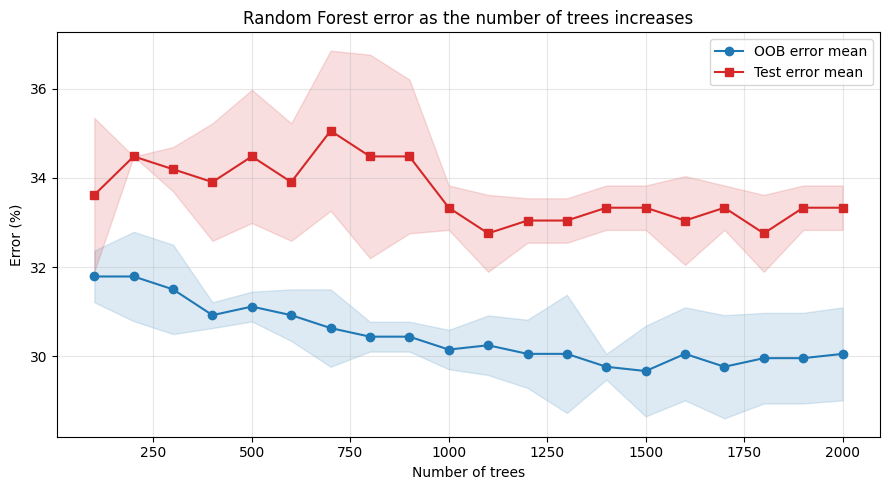

In [13]:
tree_counts = list(range(100, 2001, 100))
forest_seeds = [1, 2, 3]
tree_error_rows = []

for n_trees in tree_counts:
    for model_seed in forest_seeds:
        _, metrics = evaluate_random_forest(
            TrainDB,
            TestDB,
            n_estimators=n_trees,
            model_seed=model_seed
        )
        tree_error_rows.append({
            'n_estimators': n_trees,
            'model_seed': model_seed,
            **metrics
        })

tree_error_by_seed = pd.DataFrame(tree_error_rows)
tree_error_summary = tree_error_by_seed.groupby('n_estimators').agg(
    oob_error_mean=('oob_error', 'mean'),
    oob_error_std=('oob_error', 'std'),
    test_error_mean=('test_error', 'mean'),
    test_error_std=('test_error', 'std'),
    false_negatives_mean=('false_negatives', 'mean'),
    sensitivity_mean=('sensitivity', 'mean')
).reset_index()

tree_error_display = tree_error_summary.copy()
for col in ['oob_error_mean', 'oob_error_std', 'test_error_mean', 'test_error_std', 'sensitivity_mean']:
    tree_error_display[col] = 100 * tree_error_display[col]

print('Evolution of OOB and test error by number of trees')
display(tree_error_display.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(tree_error_display['n_estimators'], tree_error_display['oob_error_mean'], marker='o', label='OOB error mean', color='#1f77b4')
ax.fill_between(
    tree_error_display['n_estimators'],
    tree_error_display['oob_error_mean'] - tree_error_display['oob_error_std'],
    tree_error_display['oob_error_mean'] + tree_error_display['oob_error_std'],
    color='#1f77b4',
    alpha=0.15
)
ax.plot(tree_error_display['n_estimators'], tree_error_display['test_error_mean'], marker='s', label='Test error mean', color='#d62728')
ax.fill_between(
    tree_error_display['n_estimators'],
    tree_error_display['test_error_mean'] - tree_error_display['test_error_std'],
    tree_error_display['test_error_mean'] + tree_error_display['test_error_std'],
    color='#d62728',
    alpha=0.15
)
ax.set_title('Random Forest error as the number of trees increases')
ax.set_xlabel('Number of trees')
ax.set_ylabel('Error (%)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Class-weight comparison averaged across model seeds


,setting,test_accuracy_mean,test_accuracy_std,test_error_mean,false_negatives_mean,false_positives_mean,sensitivity_mean,specificity_mean
0,No class weight,65.34,1.12,34.66,21.2,19.0,47.0,75.00
1,"Equal weights {0:0.5, 1:0.5}",65.34,1.12,34.66,21.2,19.0,47.0,75.00
2,Balanced weights,65.69,1.97,34.31,22.2,17.6,44.5,76.84
3,"More CHD weight {0:0.35, 1:0.65}",65.52,0.61,34.48,22.4,17.6,44.0,76.84


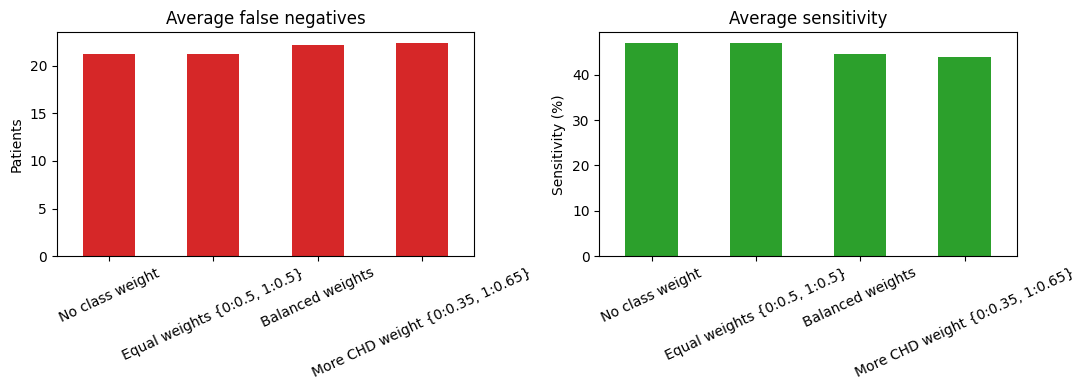

In [14]:
class_weight_options = [
    ('No class weight', None),
    ('Equal weights {0:0.5, 1:0.5}', {0: 0.5, 1: 0.5}),
    ('Balanced weights', 'balanced'),
    ('More CHD weight {0:0.35, 1:0.65}', {0: 0.35, 1: 0.65})
]
class_weight_seeds = [1, 2, 3, 4, 5]
class_weight_rows = []

for label, weights in class_weight_options:
    for model_seed in class_weight_seeds:
        _, metrics = evaluate_random_forest(
            TrainDB,
            TestDB,
            n_estimators=500,
            model_seed=model_seed,
            class_weight=weights
        )
        class_weight_rows.append({
            'setting': label,
            'model_seed': model_seed,
            **metrics
        })

class_weight_results = pd.DataFrame(class_weight_rows)
class_weight_summary = class_weight_results.groupby('setting').agg(
    test_accuracy_mean=('test_accuracy', 'mean'),
    test_accuracy_std=('test_accuracy', 'std'),
    test_error_mean=('test_error', 'mean'),
    false_negatives_mean=('false_negatives', 'mean'),
    false_positives_mean=('false_positives', 'mean'),
    sensitivity_mean=('sensitivity', 'mean'),
    specificity_mean=('specificity', 'mean')
).reindex([label for label, _ in class_weight_options]).reset_index()

class_weight_display = class_weight_summary.copy()
for col in ['test_accuracy_mean', 'test_accuracy_std', 'test_error_mean', 'sensitivity_mean', 'specificity_mean']:
    class_weight_display[col] = 100 * class_weight_display[col]

print('Class-weight comparison averaged across model seeds')
display(class_weight_display.round(2))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
class_weight_display.plot(
    x='setting',
    y='false_negatives_mean',
    kind='bar',
    ax=axes[0],
    color='#d62728',
    legend=False
)
axes[0].set_title('Average false negatives')
axes[0].set_xlabel('')
axes[0].set_ylabel('Patients')
axes[0].tick_params(axis='x', rotation=25)

class_weight_display.plot(
    x='setting',
    y='sensitivity_mean',
    kind='bar',
    ax=axes[1],
    color='#2ca02c',
    legend=False
)
axes[1].set_title('Average sensitivity')
axes[1].set_xlabel('')
axes[1].set_ylabel('Sensitivity (%)')
axes[1].tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

**Answer:** Setting `class_weight = {0:0.5, 1:0.5}` gives the two classes the same relative weight, so it behaves almost the same as not using class weights. The experiment confirms that the false-negative problem is not solved by equal weights alone. If the objective is to reduce false negatives, the model should be selected with a metric such as sensitivity/recall, unequal CHD-positive weights, threshold tuning, or a cost-sensitive scoring rule instead of accuracy alone.

###  Next we will look for the best combination of parameters of the random forest classifiers by cross validation.
### **Important**: Check the memory consumption of the process.

In [15]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_depth': [10, 20, None]
}

# Set up KFold cross-validation without locking the notebook to one random seed.
kfold = KFold(n_splits=5, shuffle=True)

# Create GridSearchCV. The outer grid is parallelized; each forest runs with n_jobs=1 to reduce memory pressure.
grid_search = GridSearchCV(
    RandomForestClassifier(oob_score=True, n_jobs=1),
    param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=4,
    verbose=1
)

# Fit the grid search
grid_search.fit(X, y)

# Get the best model
best_clf = grid_search.best_estimator_

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV score: {grid_search.best_score_*100:.2f} %')
print('_'*50)

# Evaluate on test set
X_test = TestDB[InputFeatures]
y_test = TestDB['chd']
y_hat_best = best_clf.predict(X_test)

test_accuracy = accuracy_score(y_test, y_hat_best)
test_error = 1 - test_accuracy

oob_error = 1 - best_clf.oob_score_
grid_cm = confusion_matrix(y_test, y_hat_best, labels=[0, 1])
grid_tn, grid_fp, grid_fn, grid_tp = grid_cm.ravel()
grid_sensitivity = grid_tp / (grid_tp + grid_fn) if (grid_tp + grid_fn) > 0 else np.nan
grid_specificity = grid_tn / (grid_tn + grid_fp) if (grid_tn + grid_fp) > 0 else np.nan

print(f'Out of Bag estimate of the error: {oob_error*100:2.2f} %')
print(f'Test database error rate:        {test_error*100:2.2f} %')
print(f'Test accuracy:                   {test_accuracy*100:2.2f} %')
print(f'Sensitivity (CHD recall):        {grid_sensitivity*100:2.2f} %')
print(f'Specificity:                     {grid_specificity*100:2.2f} %')
print('Confusion matrix:')
display(pd.DataFrame(grid_cm, index=['True 0', 'True 1'], columns=['Predicted 0', 'Predicted 1']))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}
Best CV score: 73.13 %
__________________________________________________
Out of Bag estimate of the error: 31.50 %
Test database error rate:        36.21 %
Test accuracy:                   63.79 %
Sensitivity (CHD recall):        45.00 %
Specificity:                     73.68 %
Confusion matrix:


,Predicted 0,Predicted 1
True 0,56,20
True 1,22,18


 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear. Put both the infographic and the prompt here. The infographic should include the final final results.

**Prompt used for generation:** Create a clean academic infographic titled "Random Forests for CHD Prediction". Use a white background with blue, green, and red accents. Include compact sections for the South African Heart Disease dataset, the Random Forest workflow, seed-to-seed variability, the evolution of OOB/test error as trees increase from 100 to 2000, the class-weight experiment, and the final cross-validated results. Include the final test accuracy, OOB error, sensitivity, specificity, and confusion matrix from the executed notebook. Emphasize that false negatives remain important and that accuracy alone is not enough for a health-related classifier.

The infographic below is generated directly from the current notebook variables, so the numbers match the executed results.

In [16]:
best_tree_row = tree_error_summary.loc[tree_error_summary['test_error_mean'].idxmin()]
best_weight_row = class_weight_summary.loc[class_weight_summary['sensitivity_mean'].idxmax()]

short_weight_labels = {
    'No class weight': 'No weight',
    'Equal weights {0:0.5, 1:0.5}': 'Equal weights',
    'Balanced weights': 'Balanced',
    'More CHD weight {0:0.35, 1:0.65}': 'More CHD weight'
}
class_weight_infographic = class_weight_display.copy()
class_weight_infographic['setting'] = class_weight_infographic['setting'].map(short_weight_labels).fillna(class_weight_infographic['setting'])

fig = plt.figure(figsize=(16, 12), facecolor='white')
fig.suptitle('Random Forests for CHD Prediction', fontsize=24, fontweight='bold')
gs = fig.add_gridspec(3, 3, height_ratios=[1.05, 1.25, 1.05], hspace=0.62, wspace=0.35)

panel_colors = ['#1f77b4', '#2ca02c', '#d62728']


def make_text_panel(ax, title, lines, color):
    ax.set_facecolor('#f8fafc')
    for spine in ax.spines.values():
        spine.set_edgecolor('#d9e2ec')
        spine.set_linewidth(1.1)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.text(0.04, 0.88, title, transform=ax.transAxes, fontsize=14, fontweight='bold', color=color, va='top')
    y_pos = 0.68
    for line in lines:
        ax.text(0.07, y_pos, line, transform=ax.transAxes, fontsize=10, va='top', color='#1f2937')
        y_pos -= 0.13

make_text_panel(
    fig.add_subplot(gs[0, 0]),
    'Dataset',
    [
        f'{len(Data)} observations',
        f'{len(InputFeatures)} input variables',
        'Target: CHD = 0 or 1',
        'famhist encoded as 0/1'
    ],
    panel_colors[0]
)
make_text_panel(
    fig.add_subplot(gs[0, 1]),
    'Workflow',
    [
        'Clean categorical data',
        'Random train/test split',
        'Train Random Forests',
        'Compare OOB and test error',
        'Tune with cross-validation'
    ],
    panel_colors[1]
)
make_text_panel(
    fig.add_subplot(gs[0, 2]),
    'Final Results',
    [
        f'Best CV accuracy: {grid_search.best_score_*100:.1f}%',
        f'Test accuracy: {test_accuracy*100:.1f}%',
        f'OOB error: {oob_error*100:.1f}%',
        f'Sensitivity: {grid_sensitivity*100:.1f}%',
        f'CM: TN={grid_tn}, FP={grid_fp}, FN={grid_fn}, TP={grid_tp}'
    ],
    panel_colors[2]
)

ax_tree = fig.add_subplot(gs[1, 0])
ax_tree.plot(tree_error_display['n_estimators'], tree_error_display['oob_error_mean'], marker='o', color='#1f77b4', linewidth=2)
ax_tree.plot(tree_error_display['n_estimators'], tree_error_display['test_error_mean'], marker='s', color='#d62728', linewidth=2)
ax_tree.set_title('Trees vs. Error\nblue: OOB | red: Test', fontsize=12, fontweight='bold', pad=10)
ax_tree.set_xlabel('Number of trees')
ax_tree.set_ylabel('Error (%)')
ax_tree.grid(True, alpha=0.25)

ax_seed = fig.add_subplot(gs[1, 1])
ax_seed.plot(seed_results_display['split_seed'], seed_results_display['oob_error'], marker='o', color='#1f77b4', linewidth=2)
ax_seed.plot(seed_results_display['split_seed'], seed_results_display['test_error'], marker='s', color='#d62728', linewidth=2)
ax_seed.set_title('Different Split Seeds\nblue: OOB | red: Test', fontsize=12, fontweight='bold', pad=10)
ax_seed.set_xlabel('Split seed')
ax_seed.set_ylabel('Error (%)')
ax_seed.grid(True, alpha=0.25)

ax_weight = fig.add_subplot(gs[1, 2])
ax_weight.axis('off')
ax_weight.set_title('Class Weight Comparison', fontsize=12, fontweight='bold', pad=10)
weight_table = class_weight_infographic[[
    'setting',
    'test_accuracy_mean',
    'sensitivity_mean',
    'false_negatives_mean'
]].copy()
weight_table.columns = ['Setting', 'Accuracy', 'Sensitivity', 'False neg.']
weight_table['Accuracy'] = weight_table['Accuracy'].map(lambda value: f'{value:.1f}%')
weight_table['Sensitivity'] = weight_table['Sensitivity'].map(lambda value: f'{value:.1f}%')
weight_table['False neg.'] = weight_table['False neg.'].map(lambda value: f'{value:.1f}')
table = ax_weight.table(
    cellText=weight_table.values,
    colLabels=weight_table.columns,
    cellLoc='center',
    colLoc='center',
    loc='center',
    colWidths=[0.34, 0.22, 0.25, 0.23]
)
table.auto_set_font_size(False)
table.set_fontsize(8.5)
table.scale(1.0, 1.55)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor('#d9e2ec')
    if row == 0:
        cell.set_facecolor('#e8f2ff')
        cell.set_text_props(weight='bold', color='#1f2937')
    else:
        cell.set_facecolor('#ffffff' if row % 2 else '#f8fafc')

ax_importance = fig.add_subplot(gs[2, 0])
importance_display = feature_importance_df.head(6).sort_values('Importance')
ax_importance.barh(importance_display['Feature'], 100 * importance_display['Importance'], color='#4c78a8')
ax_importance.set_title('Top Feature Importances', fontsize=12, fontweight='bold', pad=10)
ax_importance.set_xlabel('Importance (%)')
ax_importance.grid(True, axis='x', alpha=0.25)

ax_takeaway = fig.add_subplot(gs[2, 1:])
ax_takeaway.set_facecolor('#f8fafc')
for spine in ax_takeaway.spines.values():
    spine.set_edgecolor('#d9e2ec')
    spine.set_linewidth(1.1)
ax_takeaway.set_xticks([])
ax_takeaway.set_yticks([])
best_weight_label = short_weight_labels.get(best_weight_row.setting, str(best_weight_row.setting))
takeaways = [
    f'Best mean test error across tree counts: {best_tree_row.test_error_mean*100:.1f}% at {int(best_tree_row.n_estimators)} trees.',
    f'Highest average sensitivity in the class-weight experiment: {best_weight_label}.',
    'OOB error tracks held-out test error, but the seed study shows meaningful train/test split variability.',
    'False negatives remain important, so sensitivity/recall should be reported with accuracy.'
]
ax_takeaway.text(0.03, 0.82, 'Key Takeaways', transform=ax_takeaway.transAxes, fontsize=13, fontweight='bold', color='#374151')
y_pos = 0.62
for line in takeaways:
    ax_takeaway.text(0.05, y_pos, line, transform=ax_takeaway.transAxes, fontsize=10.5, color='#1f2937', va='top')
    y_pos -= 0.18

infographic_path = 'InfographicPractice7.png'
fig.savefig(infographic_path, dpi=200, bbox_inches='tight')
plt.close(fig)
print(f'Infographic saved to {infographic_path}')

Infographic saved to InfographicPractice7.png


**Infographic generated from the current notebook results:**

![Random Forests for CHD Prediction](InfographicPractice7.png)

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.

The executive report below summarizes the executed notebook results.

### Executive report

This practice studied Random Forests on the South African Heart Disease dataset. The workflow encoded `famhist`, removed the row identifier, split the data into train and test sets, trained a baseline Random Forest, compared the Out-of-Bag error with the held-out test error, analyzed feature importance, studied the effect of the number of trees, tested class weights, and used cross-validation to select hyperparameters.

The main result from the current execution is a cross-validated Random Forest with **73.1%** mean CV accuracy and **63.8%** held-out test accuracy. Its OOB error is **31.5%**, close enough to the test error to be useful as an internal generalization estimate. The final confusion matrix is TN=56, FP=20, FN=22, TP=18, with sensitivity **45.0%** and specificity **73.7%**.

The main challenge is variability: changing the train/test split seed changes the test error and the number of false negatives. This is expected because the dataset is small, moderately imbalanced, and contains correlated risk factors. The feature-importance results are more stable than a single decision tree, but they should still be interpreted as predictive importance rather than causal importance.

The most important practical difficulty is the false-negative rate. Equal class weights `{0:0.5, 1:0.5}` do not really solve this because they keep both classes at the same relative cost. For a health-related screening problem, the next step should optimize sensitivity/recall directly, try unequal CHD-positive weights or threshold tuning, compare against logistic regression and gradient boosting, and report accuracy together with sensitivity, specificity, ROC-AUC, and calibration.